In [7]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))

In [9]:
from src.forecasting_pipeline_timesfm import forecast_crypto_prices
from src.evaluate_forecasts import evaluate_forecasts
from config.config import DATA_DIR
from src.data_loading import load_crypto_data, preprocess_data, split_data

OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [54]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_directory = DATA_DIR
train_end_date = "2023-12-31"

if not os.path.exists(os.path.join(data_directory, 'raw')):
    print(f"Error: '{DATA_DIR}\raw' directory not found.")
else:
    # Generate forecasts and save results
    forecast_results = forecast_crypto_prices(crypto_symbols, data_directory, train_end_date)

    # Evaluate the forecasts
    evaluation_results = evaluate_forecasts(OUTPUTS_DIR, crypto_symbols,"Forecasted_Close", "Close")

    # Print the evaluation results
    print("\nEvaluation Results:")
    print(evaluation_results)
    for symbol, metrics in evaluation_results.items():
        print(f"\n--- {symbol} ---")
        print("Test Set Metrics:")
        for metric, value in metrics.get('test', {}).items():
            print(f"{metric}: {value}")
        print("Train Set Metrics:") # Note: Train set evaluation might be limited with this forecasting approach
        for metric, value in metrics.get('train', {}).items():
            print(f"{metric}: {value}")

Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Forecasts for BTC-USD saved to C:\Studies\Other_Repos\ts_foundational_models_daily_crpytocurrency_predictions\data\outputs\BTC-USD_forecasts.csv


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Forecasts for BNB-USD saved to C:\Studies\Other_Repos\ts_foundational_models_daily_crpytocurrency_predictions\data\outputs\BNB-USD_forecasts.csv


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Forecasts for ETH-USD saved to C:\Studies\Other_Repos\ts_foundational_models_daily_crpytocurrency_predictions\data\outputs\ETH-USD_forecasts.csv


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Forecasts for SOL-USD saved to C:\Studies\Other_Repos\ts_foundational_models_daily_crpytocurrency_predictions\data\outputs\SOL-USD_forecasts.csv

Evaluation Results:
{'BTC-USD': {'test': {'MAPE': 34.960197684642, 'ME': 24695.05951067281, 'MAE': 24982.439328978824, 'MPE': 34.26637829912371, 'RMSE': 28862.871139636267, 'R': -0.10327547478809575, 'Scalar Product': -8902604.158113396, 'Return Score': 0.4876712328767123, 'Long Return': 0.531578947368421, 'Short Return': 0.44, 'Mean Directional Accuracy': 0.4876712328767123, 'Mean Directional Accuracy Positive': 0.531578947368421, 'Mean Directional Accuracy Negative': 0.44}}, 'BNB-USD': {'test': {'MAPE': 38.0805655497955, 'ME': 220.99867363737513, 'MAE': 223.2652957390657, 'MPE': 37.331739063379686, 'RMSE': 246.45696062139618, 'R': 0.23411822919569264, 'Scalar Product': -332.5866364334165, 'Return Score': 0.5178082191780822, 'Long Return': 0.5026178010471204, 'Short Return': 0.5344827586206896, 'Mean Directional Accuracy': 0.5178082191780822

In [56]:
forecast_results["BTC-USD"]

,Close,Forecasted_Close
Date,,
2024-01-01 00:00:00+00:00,44167.332031,42182.468750
2024-01-02 00:00:00+00:00,44957.968750,42430.671875
2024-01-03 00:00:00+00:00,42848.175781,42283.042969
2024-01-04 00:00:00+00:00,44179.921875,42628.195312
2024-01-05 00:00:00+00:00,44162.691406,42673.726562
...,...,...
2024-12-27 00:00:00+00:00,94164.859375,42239.531250
2024-12-28 00:00:00+00:00,95163.929688,42302.261719
2024-12-29 00:00:00+00:00,93530.226562,42325.886719


In [3]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45) # Rotate x-axis labels for better readability
    
    plt.tight_layout() # Adjust layout to prevent clipping of labels
    plt.show()

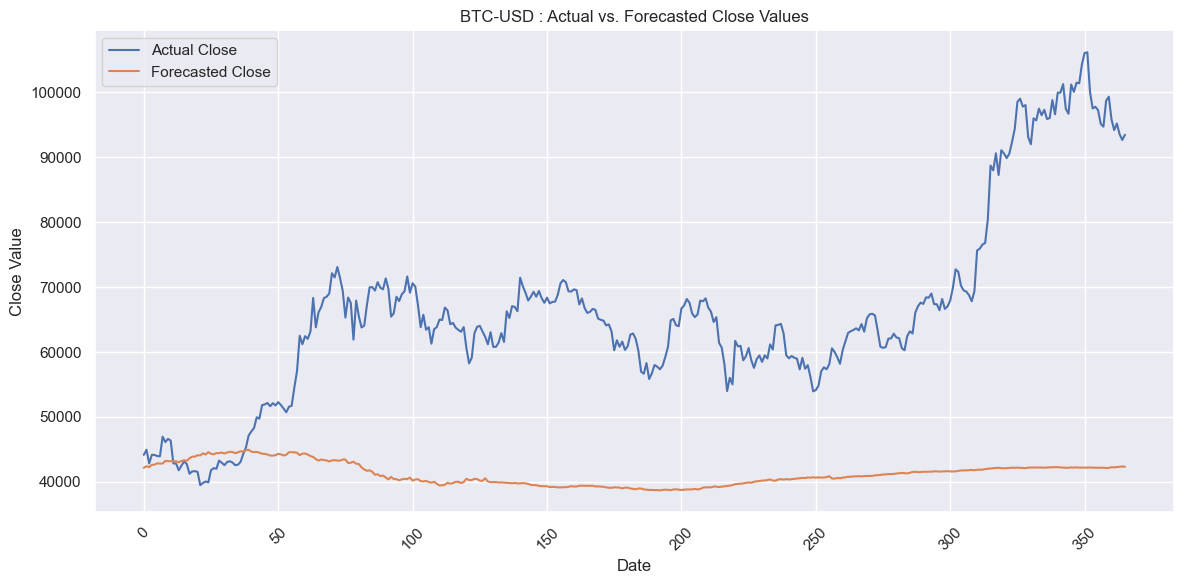

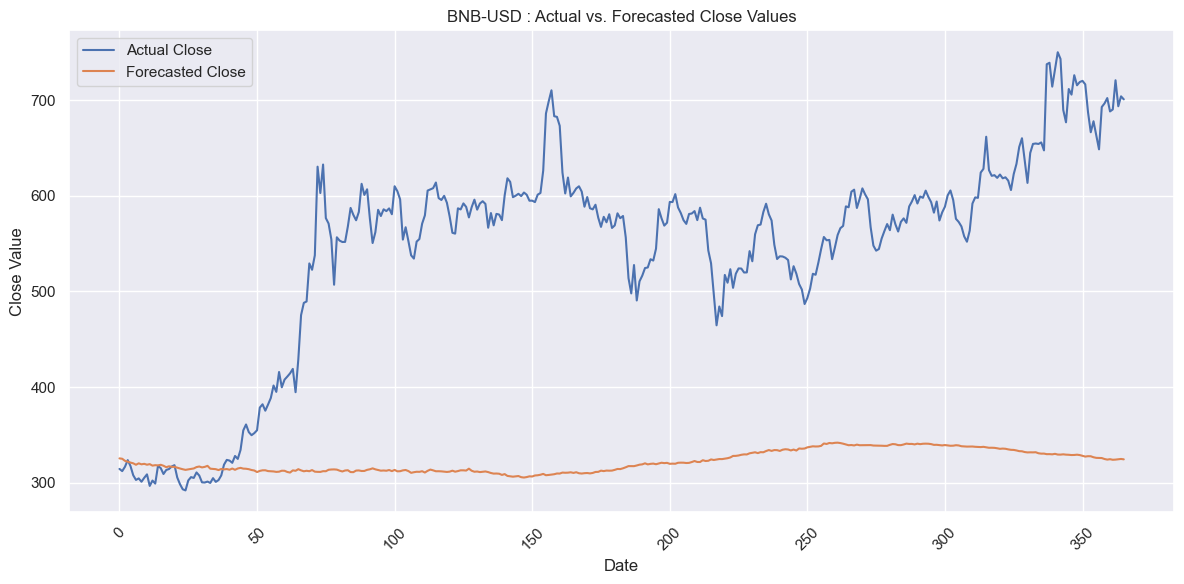

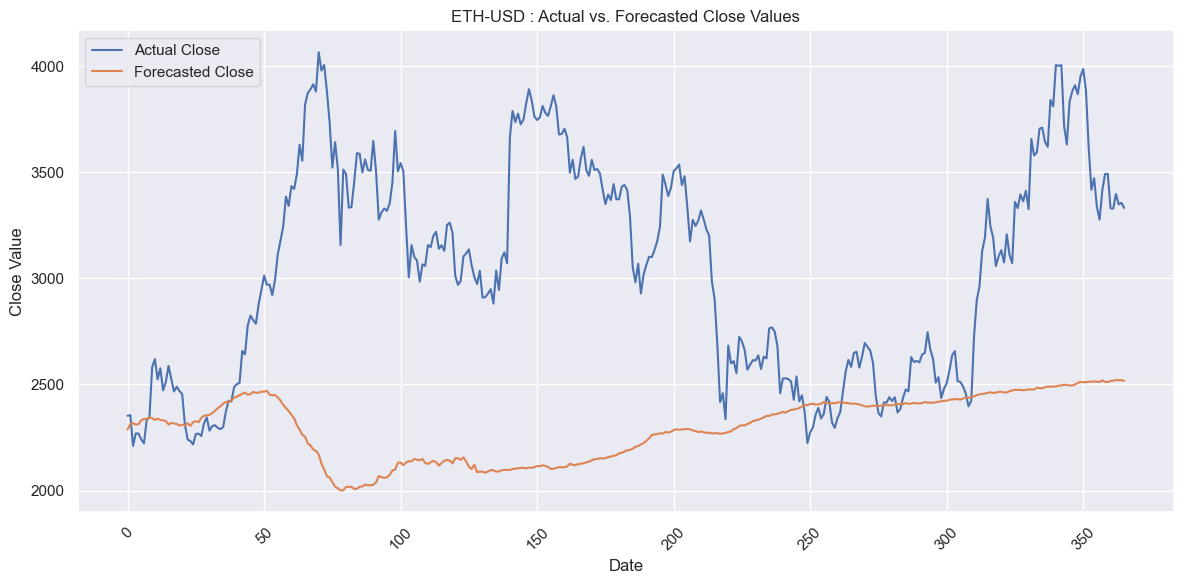

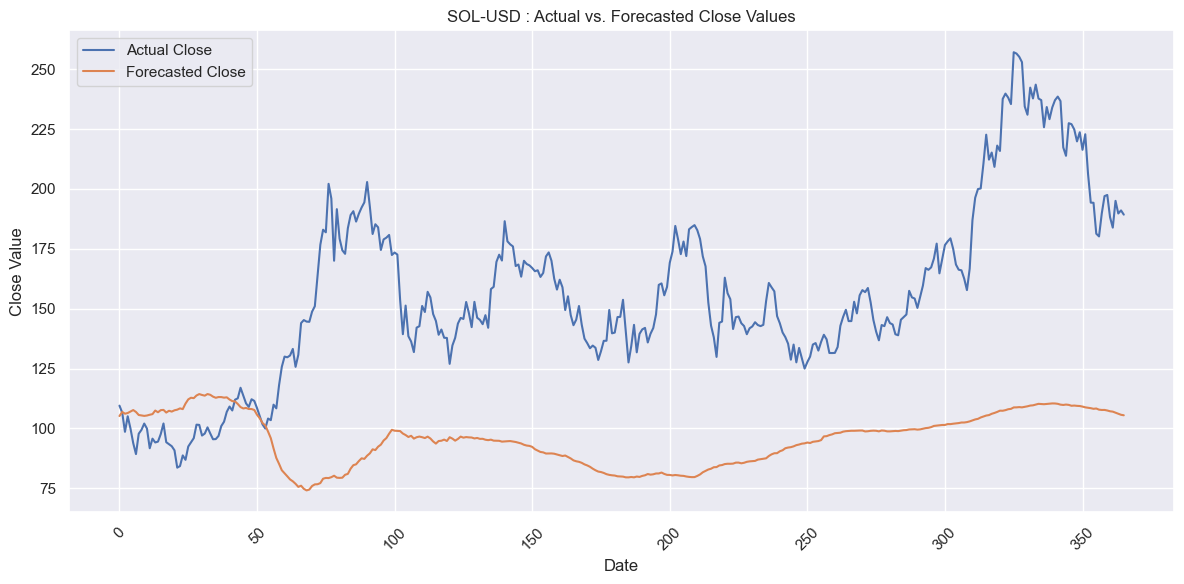

In [66]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']

for symbol in crypto_symbols:
    forecast_result_path = os.path.join(OUTPUTS_DIR, f"{symbol}_forecasts.csv")
    forecast_df = pd.read_csv(forecast_result_path)
    plot_actual_vs_forecast_for_a_symbol(symbol, forecast_df)

### Evaluate the forecasts

In [ ]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
evaluation_results = evaluate_forecasts(OUTPUTS_DIR, crypto_symbols, model = "timesfm"
                                        , forecasted_value_col = "Forecasted_Close", actual_value_col = "Close"
                                        , test_data_date = "2024-01-01")

# Print the evaluation results
print("\nEvaluation Results:")
print(evaluation_results)
for symbol, metrics in evaluation_results.items():
    print(f"\n--- {symbol} ---")
    print("Test Set Metrics:")
    for metric, value in metrics.get('test', {}).items():
        print(f"{metric}: {value}")
    print("Train Set Metrics:")  # Note: Train set evaluation might be limited with this forecasting approach
    for metric, value in metrics.get('train', {}).items():
        print(f"{metric}: {value}")

In [11]:
# Evaluate the forecasts
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
evaluation_results = evaluate_forecasts(OUTPUTS_DIR, crypto_symbols, model = ""
                                        , forecasted_value_col = "Forecasted_Close", actual_value_col = "Close"
                                        , test_data_date = "2024-01-01")

# Print the evaluation results
print("\nEvaluation Results:")
print(evaluation_results)
for symbol, metrics in evaluation_results.items():
    print(f"\n--- {symbol} ---")
    print("Test Set Metrics:")
    for metric, value in metrics.get('test', {}).items():
        print(f"{metric}: {value}")
    print("Train Set Metrics:")  # Note: Train set evaluation might be limited with this forecasting approach
    for metric, value in metrics.get('train', {}).items():
        print(f"{metric}: {value}")


Evaluation Results:
{'BTC-USD': {'test': {'MAPE': 34.960197684642, 'ME': 24695.05951067281, 'MAE': 24982.439328978824, 'MPE': 34.26637829912371, 'RMSE': 28862.871139636267, 'R': -0.10327547478809575, 'Scalar Product': -8902604.158113396, 'Return Score': 0.4876712328767123, 'Long Return': 0.531578947368421, 'Short Return': 0.44, 'Mean Directional Accuracy': 0.4876712328767123, 'Mean Directional Accuracy Positive': 0.531578947368421, 'Mean Directional Accuracy Negative': 0.44}}, 'BNB-USD': {'test': {'MAPE': 38.0805655497955, 'ME': 220.99867363737513, 'MAE': 223.2652957390657, 'MPE': 37.331739063379686, 'RMSE': 246.45696062139618, 'R': 0.23411822919569264, 'Scalar Product': -332.5866364334165, 'Return Score': 0.5178082191780822, 'Long Return': 0.5026178010471204, 'Short Return': 0.5344827586206896, 'Mean Directional Accuracy': 0.5178082191780822, 'Mean Directional Accuracy Positive': 0.5026178010471204, 'Mean Directional Accuracy Negative': 0.5344827586206896}}, 'ETH-USD': {'test': {'MAP

## 7 days horizon plot

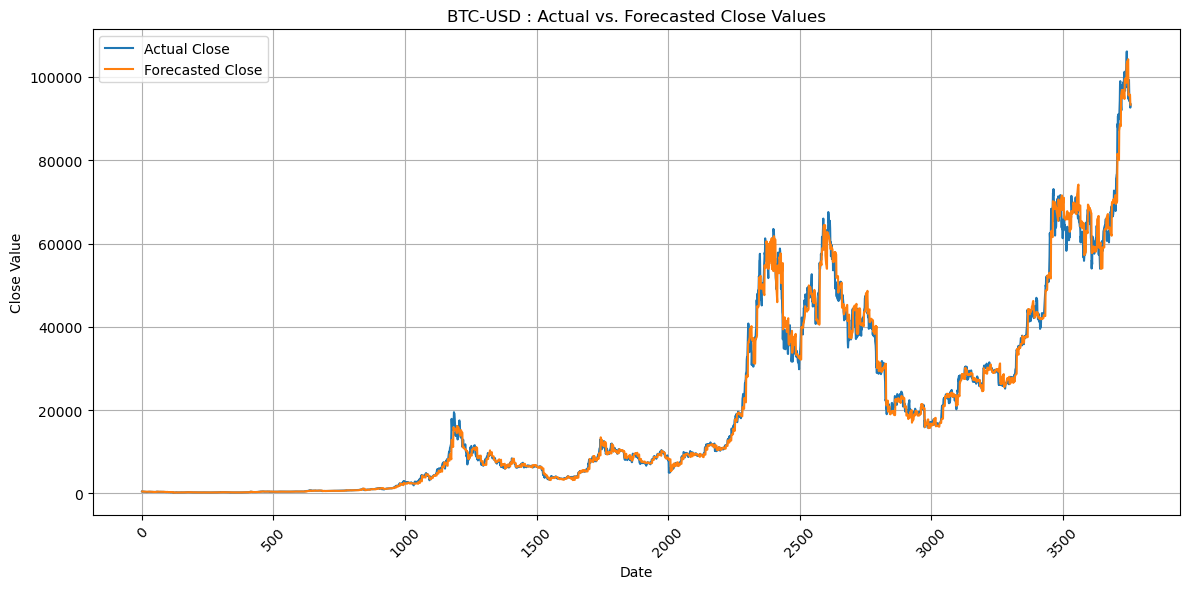

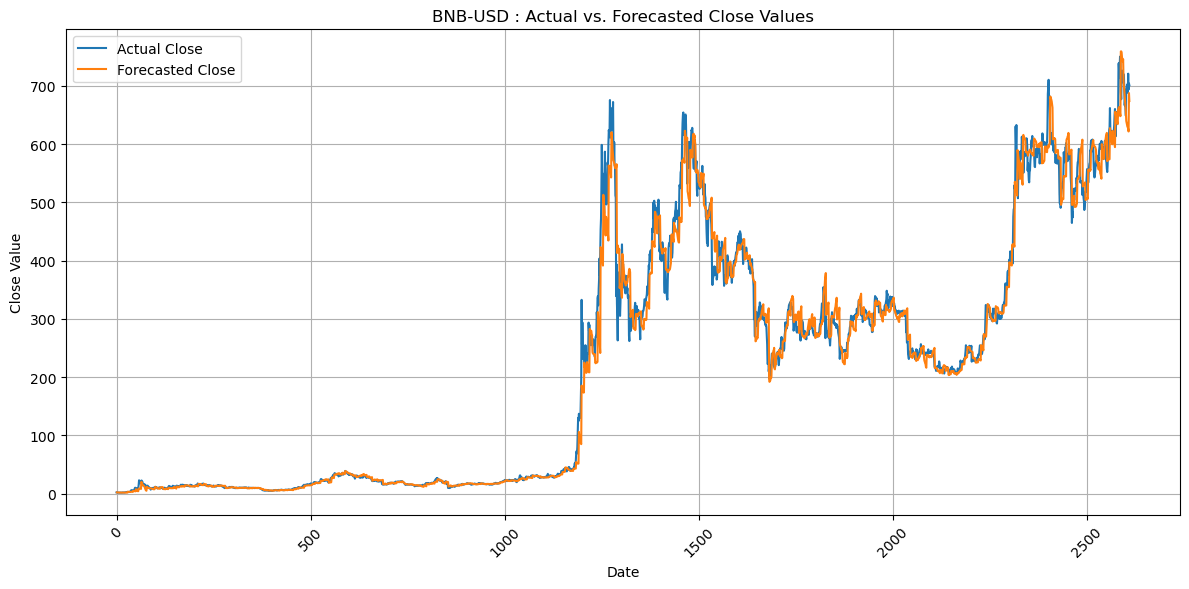

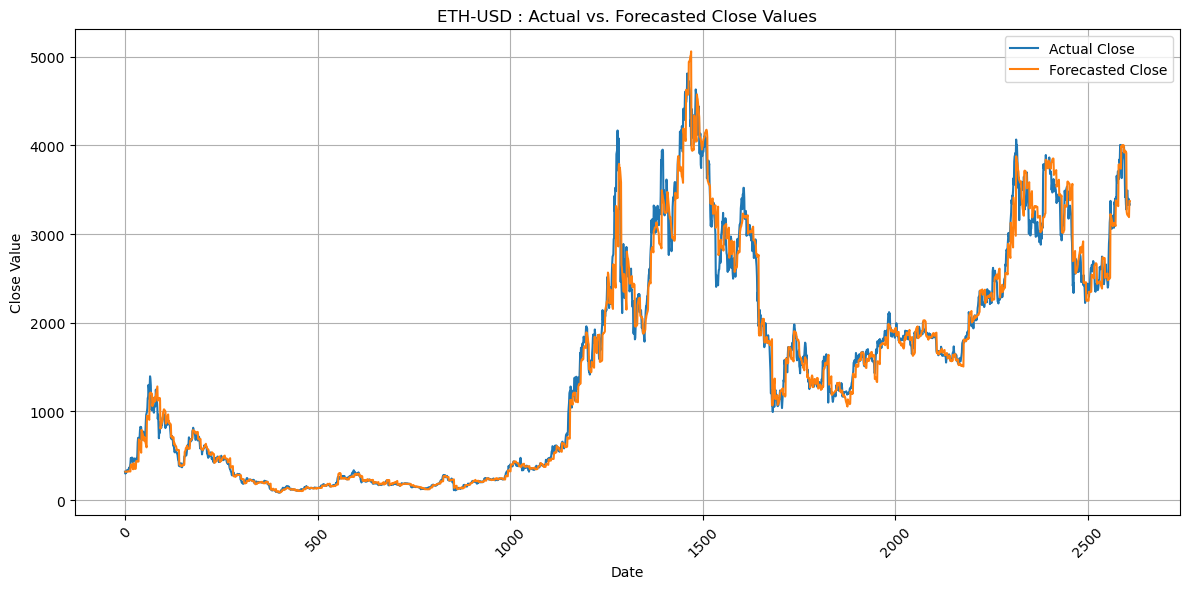

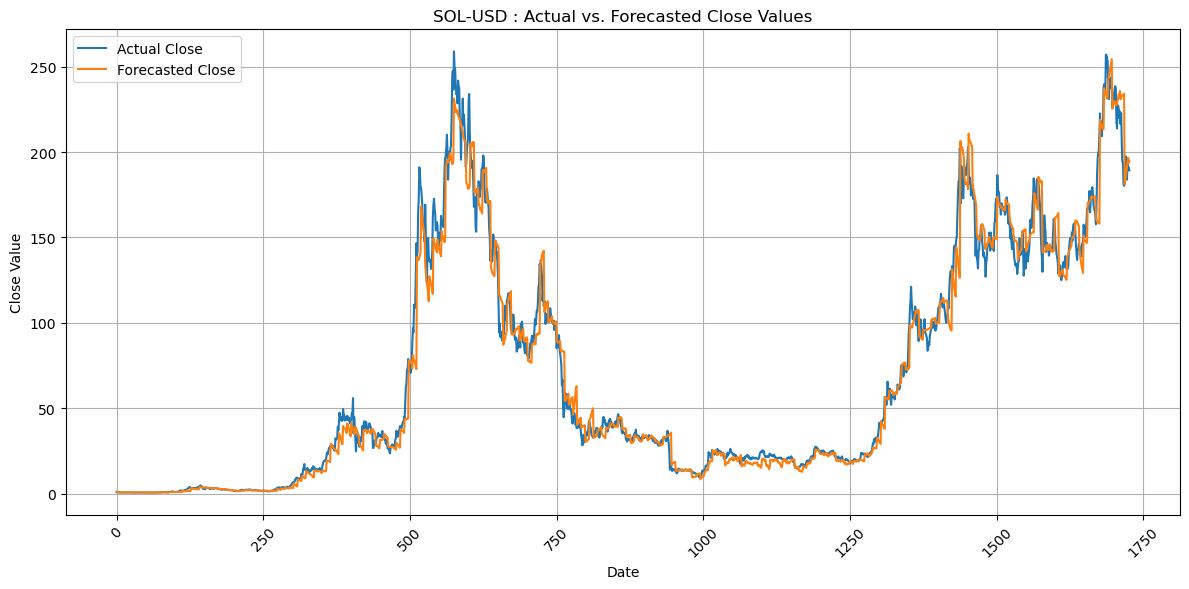

In [8]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']

for symbol in crypto_symbols:
    forecast_result_path = os.path.join(OUTPUTS_DIR, f"{symbol}_timesfm_forecasts.csv")
    forecast_df = pd.read_csv(forecast_result_path)
    plot_actual_vs_forecast_for_a_symbol(symbol, forecast_df)

### Evaluate the forecasts

In [10]:
# Evaluate the forecasts
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
evaluation_results = evaluate_forecasts(OUTPUTS_DIR, crypto_symbols, model = "timesfm"
                                        , forecasted_value_col = "Forecasted_Close", actual_value_col = "Close"
                                        , test_data_date = "2024-01-01")

# Print the evaluation results
print("\nEvaluation Results:")
print(evaluation_results)
for symbol, metrics in evaluation_results.items():
    print(f"\n--- {symbol} ---")
    print("Test Set Metrics:")
    for metric, value in metrics.get('test', {}).items():
        print(f"{metric}: {value}")
    print("Train Set Metrics:")  # Note: Train set evaluation might be limited with this forecasting approach
    for metric, value in metrics.get('train', {}).items():
        print(f"{metric}: {value}")


Evaluation Results:
{'BTC-USD': {'test': {'MAPE': 5.0090320714907834, 'ME': 75.72736586407103, 'MAE': 3295.2364158982236, 'MPE': -0.09374790941273861, 'RMSE': 4176.629305094604, 'R': 0.9588759818755193, 'Scalar Product': 175626940.4292031, 'Return Score': 0.4986301369863014, 'Long Return': 0.5421052631578948, 'Short Return': 0.4514285714285714, 'Mean Directional Accuracy': 0.4986301369863014, 'Mean Directional Accuracy Positive': 0.5421052631578948, 'Mean Directional Accuracy Negative': 0.4514285714285714}}, 'BNB-USD': {'test': {'MAPE': 5.167277526324012, 'ME': 3.934676834096442, 'MAE': 28.687767888410395, 'MPE': 0.5243570490015517, 'RMSE': 37.32385015687651, 'R': 0.9438967718208957, 'Scalar Product': -12839.4101292566, 'Return Score': 0.4794520547945205, 'Long Return': 0.4293193717277487, 'Short Return': 0.5344827586206896, 'Mean Directional Accuracy': 0.4794520547945205, 'Mean Directional Accuracy Positive': 0.4293193717277487, 'Mean Directional Accuracy Negative': 0.534482758620689